In [1]:
import torch
import torch
import pickle
from transformer_lens import HookedTransformer
import numpy as np

from utils.nodes import MLP_Node, EMBED_Node, FINAL_Node, Node, ATTN_Node

%load_ext autoreload
%autoreload 2

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.set_grad_enabled(False)

model = HookedTransformer.from_pretrained(
    'gpt2-small',
    device=DEVICE,
    torch_dtype=torch.float32
)

prompts = ['When John and Mary went to the shops, John gave the bag to', 'When John and Mary went to the shops, Mary gave the bag to', 'When Tom and James went to the park, Tom gave the ball to', 'When Tom and James went to the park, James gave the ball to', 'When Dan and Sid went to the shops, Dan gave an apple to', 'When Dan and Sid went to the shops, Sid gave an apple to', 'After Martin and Amy went to the park, Martin gave a drink to', 'After Martin and Amy went to the park, Amy gave a drink to']
answers = [(' Mary', ' John'), (' John', ' Mary'), (' James', ' Tom'), (' Tom', ' James'), (' Sid', ' Dan'), (' Dan', ' Sid'), (' Amy', ' Martin'), (' Martin', ' Amy')]
prompts_fixed_pos = prompts[0::2]
answers_fixed_pos = answers[0::2]


Loaded pretrained model gpt2-small into HookedTransformer


In [3]:
circuit_path = './detected_circuit_gpt2_ioi_absolute_indirect_effect_0.00025_bs8_l15_20250806_184050.pkl'

complete_paths, incomplete_paths = pickle.load(open(circuit_path, 'rb'))
print(f'Loaded {len(complete_paths)} complete paths and {len(incomplete_paths)} incomplete paths from {circuit_path}')

Loaded 3414 complete paths and 0 incomplete paths from ./detected_circuit_gpt2_ioi_absolute_indirect_effect_0.00025_bs8_l15_20250806_184050.pkl


In [4]:
def find_nodes(complete_paths):
	nodes = set()
	for (_, path) in complete_paths:
		for node in path:
			if isinstance(node, Node):
				if hasattr(node, "head"):
					nodes.add(node.__class__(layer=node.layer, head=node.head))
				else:
					nodes.add(node.__class__(layer=node.layer))
	return nodes

def find_edges(complete_paths):
	edges = set()
	for (_, path) in complete_paths:
		for i in range(len(path) - 1):
			if isinstance(path[i], Node) and isinstance(path[i + 1], Node):
				node1 = path[i]
				node2 = path[i + 1]
				if hasattr(node1, "head"):
					if hasattr(node2, "head"):
						edges.add((node1.__class__(layer=node1.layer, head=node1.head), node2.__class__(layer=node2.layer, head=node2.head)))
					else:
						edges.add((node1.__class__(layer=node1.layer, head=node1.head), node2.__class__(layer=node2.layer)))
				else:
					if hasattr(node2, "head"):
						edges.add((node1.__class__(layer=node1.layer), node2.__class__(layer=node2.layer, head=node2.head)))
					else:
						edges.add((node1.__class__(layer=node1.layer), node2.__class__(layer=node2.layer)))
	return edges

our_nodes = find_nodes(complete_paths)
our_edges = find_edges(complete_paths)

print(f'In our circuit, there are {len(our_nodes)} nodes and {len(our_edges)} edges.')


In our circuit, there are 78 nodes and 548 edges.


In [5]:
gorund_truth_nodes = set([
	ATTN_Node(layer=2, head=2), # Previous token head
	ATTN_Node(layer=4, head=11), # Previous token head
	ATTN_Node(layer=0, head=1), # Duplicate token head
	ATTN_Node(layer=0, head=10), # Duplicate token head
	ATTN_Node(layer=3, head=0), # Duplicate token head
	ATTN_Node(layer=5, head=5), # Induction head
	ATTN_Node(layer=6, head=9), # Induction head
	ATTN_Node(layer=5, head=8), # Induction head
	ATTN_Node(layer=5, head=9), # Induction head
	ATTN_Node(layer=7, head=3), # S-Inhibition head
	ATTN_Node(layer=7, head=9), # S-Inhibition head
	ATTN_Node(layer=8, head=6), # S-Inhibition head
	ATTN_Node(layer=8, head=10), # S-Inhibition head
	ATTN_Node(layer=9, head=9), # Name mover head
	ATTN_Node(layer=9, head=6), # Name mover head
	ATTN_Node(layer=10, head=0), # Name mover head
	ATTN_Node(layer=9, head=0), # Backup Name mover head
	ATTN_Node(layer=9, head=7), # Backup Name mover head
	ATTN_Node(layer=10, head=1), # Backup Name mover head
	ATTN_Node(layer=10, head=2), # Backup Name mover head
	ATTN_Node(layer=10, head=6), # Backup Name mover head
	ATTN_Node(layer=10, head=10), # Backup Name mover head
	ATTN_Node(layer=11, head=2), # Backup Name mover head
	ATTN_Node(layer=11, head=9)  # Backup Name mover head
])

ground_truth_dict = {
	'previous_token_heads': {ATTN_Node(layer=2, head=2), ATTN_Node(layer=4, head=11)},
	'duplicate_token_heads': {ATTN_Node(layer=0, head=1), ATTN_Node(layer=0, head=10), ATTN_Node(layer=3, head=0)},
	'induction_heads': {ATTN_Node(layer=5, head=5), ATTN_Node(layer=6, head=9), ATTN_Node(layer=5, head=8), ATTN_Node(layer=5, head=9)},
	's_inhibition_heads': {ATTN_Node(layer=7, head=3), ATTN_Node(layer=7, head=9), ATTN_Node(layer=8, head=6), ATTN_Node(layer=8, head=10)},
	'name_mover_heads': {ATTN_Node(layer=9, head=9), ATTN_Node(layer=9, head=6), ATTN_Node(layer=10, head=0)},
	'backup_name_mover_heads': {ATTN_Node(layer=9, head=0), ATTN_Node(layer=9, head=7), ATTN_Node(layer=10, head=1), ATTN_Node(layer=10, head=2), ATTN_Node(layer=10, head=6), ATTN_Node(layer=10, head=10), ATTN_Node(layer=11, head=2), ATTN_Node(layer=11, head=9)},
	'negative_name_mover_heads': {ATTN_Node(layer=10, head=7), ATTN_Node(layer=11, head=10)},
	'mlps': {MLP_Node(layer=l) for l in range(12)},
	'embeds': {EMBED_Node(layer=0)},
	'finals': {FINAL_Node(layer=11)}
}

ground_edges = []

# Previous token heads write to duplicate induction heads and read from input 
for previous_token_head in ground_truth_dict['previous_token_heads']:
	ground_edges.append((EMBED_Node(layer=0), previous_token_head))
	for induction_head in ground_truth_dict['induction_heads']:
		ground_edges.append((previous_token_head, induction_head))

# duplicate token heads write to induction heads and read from input
for duplicate_token_head in ground_truth_dict['duplicate_token_heads']:
	ground_edges.append((EMBED_Node(layer=0), duplicate_token_head))
	for induction_head in ground_truth_dict['induction_heads']:
		ground_edges.append((duplicate_token_head, induction_head))

# induction heads write to s_inhibition heads
for induction_head in ground_truth_dict['induction_heads']:
	for s_inhibition_head in ground_truth_dict['s_inhibition_heads']:
		ground_edges.append((induction_head, s_inhibition_head))

# s_inhibition heads write to name (also backup and negative) mover heads, and read from induction heads
for s_inhibition_head in ground_truth_dict['s_inhibition_heads']:
	ground_edges.append((EMBED_Node(layer=0), s_inhibition_head))
	for name_mover_head in ground_truth_dict['name_mover_heads']:
		ground_edges.append((s_inhibition_head, name_mover_head))

	for backup_name_mover_head in ground_truth_dict['backup_name_mover_heads']:
		ground_edges.append((s_inhibition_head, backup_name_mover_head))

	for negative_name_mover_head in ground_truth_dict['negative_name_mover_heads']:
		ground_edges.append((s_inhibition_head, negative_name_mover_head))

for name_mover_head in ground_truth_dict['name_mover_heads']:
	ground_edges.append((EMBED_Node(layer=0), name_mover_head))
	ground_edges.append((name_mover_head, FINAL_Node(layer=11)))

for name_mover_head in ground_truth_dict['backup_name_mover_heads']:
	ground_edges.append((EMBED_Node(layer=0), name_mover_head))
	ground_edges.append((name_mover_head, FINAL_Node(layer=11)))

for negative_name_mover_head in ground_truth_dict['negative_name_mover_heads']:
	ground_edges.append((EMBED_Node(layer=0), negative_name_mover_head))
	ground_edges.append((negative_name_mover_head, FINAL_Node(layer=11)))
ground_edges = set(ground_edges)
 
ground_nodes = set()
for key in ground_truth_dict.keys():
	if key == 'mlps':
		continue
	ground_nodes.update(ground_truth_dict[key]) 
print(f"Without considering MLPs, there are {len(ground_nodes)} nodes and {len(ground_edges)} edges in the ground truth circuit.")


ground_edges_with_mlp = ground_edges.copy()
for mlp in ground_truth_dict['mlps']:
	for key in ground_truth_dict.keys():
		for node in ground_truth_dict[key]:
			if isinstance(node, MLP_Node):
				if mlp.layer < node.layer:
					ground_edges_with_mlp.add((mlp, node))
				elif mlp.layer > node.layer:
					ground_edges_with_mlp.add((node, mlp))
			elif isinstance(node, ATTN_Node):
				if mlp.layer < node.layer:
					ground_edges_with_mlp.add((mlp, node))
				else:
					ground_edges_with_mlp.add((node, mlp))
			elif isinstance(node, EMBED_Node):
				ground_edges_with_mlp.add((mlp, node))
			elif isinstance(node, FINAL_Node):
				ground_edges_with_mlp.add((node, mlp))

ground_nodes_with_mlp = ground_nodes.copy()
ground_nodes_with_mlp.update(ground_truth_dict['mlps'])

print(f"When considering MLPs, there are {len(ground_nodes_with_mlp)} nodes and {len(ground_edges_with_mlp)} edges in the ground truth circuit.")

Without considering MLPs, there are 28 nodes and 123 edges in the ground truth circuit.
When considering MLPs, there are 40 nodes and 525 edges in the ground truth circuit.


## Comparison

### 1 Circuit Overlaps

#### 1.1 Nodes

In [6]:
total_nodes = model.cfg.n_layers * (model.cfg.n_heads + 1) + 2 # ATTN, MLPs and EMBED + FINAL

print(f'The total number of nodes in the model is {total_nodes}.')

print('\n\nConsidering the ground truth without MLPs')

print(f'Our circuit has {len(our_nodes)} nodes, which is {len(our_nodes) / total_nodes * 100:.2f}% of the total nodes in the model.')
print(f'The ground truth circuit has {len(ground_nodes)} nodes, which is {len(ground_nodes) / total_nodes * 100:.2f}% of the total nodes in the model.')

intersection = our_nodes.intersection(ground_nodes)
union = our_nodes.union(ground_nodes)

print(f'The intersection of our circuit with the ground truth circuit has {len(intersection)} nodes.')
print(f'  The percentages of ground truth nodes in our circuit is {len(intersection) / len(ground_nodes) * 100:.2f}%.')
print(f'    Missing nodes are {ground_nodes - intersection}.')
print(f'  The percentages of our nodes in the ground truth circuit is {len(intersection) / len(our_nodes) * 100:.2f}%.')


# ==================================
print('\n\nConsidering the ground truth with MLPs')

print(f'Our circuit has {len(our_nodes)} nodes, which is {len(our_nodes) / total_nodes * 100:.2f}% of the total nodes in the model.')
print(f'The ground truth circuit has {len(ground_nodes_with_mlp)} nodes, which is {len(ground_nodes_with_mlp) / total_nodes * 100:.2f}% of the total nodes in the model.')

intersection = our_nodes.intersection(ground_nodes_with_mlp)
union = our_nodes.union(ground_nodes_with_mlp)

print(f'The intersection of our circuit with the ground truth circuit has {len(intersection)} nodes.')
print(f'  The percentages of ground truth nodes in our circuit is {len(intersection) / len(ground_nodes_with_mlp) * 100:.2f}%.')
print(f'    Missing nodes are {ground_nodes_with_mlp - intersection}.')
print(f'  The percentages of our nodes in the ground truth circuit is {len(intersection) / len(our_nodes) * 100:.2f}%.')


The total number of nodes in the model is 158.


Considering the ground truth without MLPs
Our circuit has 78 nodes, which is 49.37% of the total nodes in the model.
The ground truth circuit has 28 nodes, which is 17.72% of the total nodes in the model.
The intersection of our circuit with the ground truth circuit has 27 nodes.
  The percentages of ground truth nodes in our circuit is 96.43%.
    Missing nodes are {ATTN_Node(layer=4, head=11, position=None, keyvalue_position=None, patch_query=True, patch_keyvalue=True)}.
  The percentages of our nodes in the ground truth circuit is 34.62%.


Considering the ground truth with MLPs
Our circuit has 78 nodes, which is 49.37% of the total nodes in the model.
The ground truth circuit has 40 nodes, which is 25.32% of the total nodes in the model.
The intersection of our circuit with the ground truth circuit has 39 nodes.
  The percentages of ground truth nodes in our circuit is 97.50%.
    Missing nodes are {ATTN_Node(layer=4, head=11, positi

#### 1.2 Edges

In [7]:
total_edges = 32491

print('\n\nConsidering the ground truth without MLPs')

print(f'Our circuit has {len(our_edges)} edges, which is {len(our_edges) / total_edges * 100:.2f}% of the total edges in the model.')
print(f'The ground truth circuit has {len(ground_edges)} edges, which is {len(ground_edges) / total_edges * 100:.2f}% of the total edges in the model.')

intersection = our_edges.intersection(ground_edges)
union = our_edges.union(ground_edges)

print(f'The intersection of our circuit with the ground truth circuit has {len(intersection)} edges.')
print(f'  The percentages of ground truth edges in our circuit is {len(intersection) / len(ground_edges) * 100:.2f}%.')
print(f'    Missing edges are {ground_edges - intersection}.')
print(f'  The percentages of our edges in the ground truth circuit is {len(intersection) / len(our_edges) * 100:.2f}%.')


print('\n\nConsidering the ground truth with MLPs')

print(f'Our circuit has {len(our_edges)} edges, which is {len(our_edges) / total_edges * 100:.2f}% of the total edges in the model.')
print(f'The ground truth circuit has {len(ground_edges_with_mlp)} edges, which is {len(ground_edges_with_mlp) / total_edges * 100:.2f}% of the total edges in the model.')

intersection = our_edges.intersection(ground_edges_with_mlp)
union = our_edges.union(ground_edges_with_mlp)

print(f'The intersection of our circuit with the ground truth circuit has {len(intersection)} edges.')
print(f'  The percentages of ground truth edges in our circuit is {len(intersection) / len(ground_edges_with_mlp) * 100:.2f}%.')
print(f'    Missing edges are {ground_edges_with_mlp - intersection}.')
print(f'  The percentages of our edges in the ground truth circuit is {len(intersection) / len(our_edges) * 100:.2f}%.')

print('\n\n')



Considering the ground truth without MLPs
Our circuit has 548 edges, which is 1.69% of the total edges in the model.
The ground truth circuit has 123 edges, which is 0.38% of the total edges in the model.
The intersection of our circuit with the ground truth circuit has 77 edges.
  The percentages of ground truth edges in our circuit is 62.60%.
    Missing edges are {(ATTN_Node(layer=4, head=11, position=None, keyvalue_position=None, patch_query=True, patch_keyvalue=True), ATTN_Node(layer=6, head=9, position=None, keyvalue_position=None, patch_query=True, patch_keyvalue=True)), (ATTN_Node(layer=0, head=10, position=None, keyvalue_position=None, patch_query=True, patch_keyvalue=True), ATTN_Node(layer=5, head=8, position=None, keyvalue_position=None, patch_query=True, patch_keyvalue=True)), (EMBED_Node(layer=0, position=None), ATTN_Node(layer=2, head=2, position=None, keyvalue_position=None, patch_query=True, patch_keyvalue=True)), (ATTN_Node(layer=7, head=9, position=None, keyvalue_po

### 2 Changing our circuit Threshold

In [44]:
thresholds = np.arange(0.00025, 0.025, 0.00005)

our_nodes_by_threshold = []
our_edges_by_threshold = []

our_nodes_by_threshold_no_mlps = []
our_edges_by_threshold_no_mlps = []

nodes_intersections = []
edges_intersections = []

nodes_intersections_with_mlp = []
edges_intersections_with_mlp = []

for threshold in thresholds:
	complete_paths_threshold = complete_paths.copy()
	complete_paths_threshold = [path for path in complete_paths_threshold if abs(path[0]) >= threshold]
	our_nodes_threshold = find_nodes(complete_paths_threshold)
	our_edges_threshold = find_edges(complete_paths_threshold)
	our_nodes_by_threshold_no_mlps.append({node for node in our_nodes_threshold if not isinstance(node, MLP_Node)})
	our_edges_by_threshold_no_mlps.append({edge for edge in our_edges_threshold if not (isinstance(edge[0], MLP_Node) or isinstance(edge[1], MLP_Node))})


	# Nodes part
	our_nodes_by_threshold.append(our_nodes_threshold)
	intersection = our_nodes_threshold.intersection(ground_nodes)
	nodes_intersections.append(intersection)

	intersection_with_mlp = our_nodes_threshold.intersection(ground_nodes_with_mlp)
	nodes_intersections_with_mlp.append(intersection_with_mlp)

	# Edges part
	our_edges_by_threshold.append(our_edges_threshold)
	intersection = our_edges_threshold.intersection(ground_edges)
	edges_intersections.append(intersection)

	intersection_with_mlp = our_edges_threshold.intersection(ground_edges_with_mlp)
	edges_intersections_with_mlp.append(intersection_with_mlp)

### 2.1 without MLPs

In [66]:
show_all = False

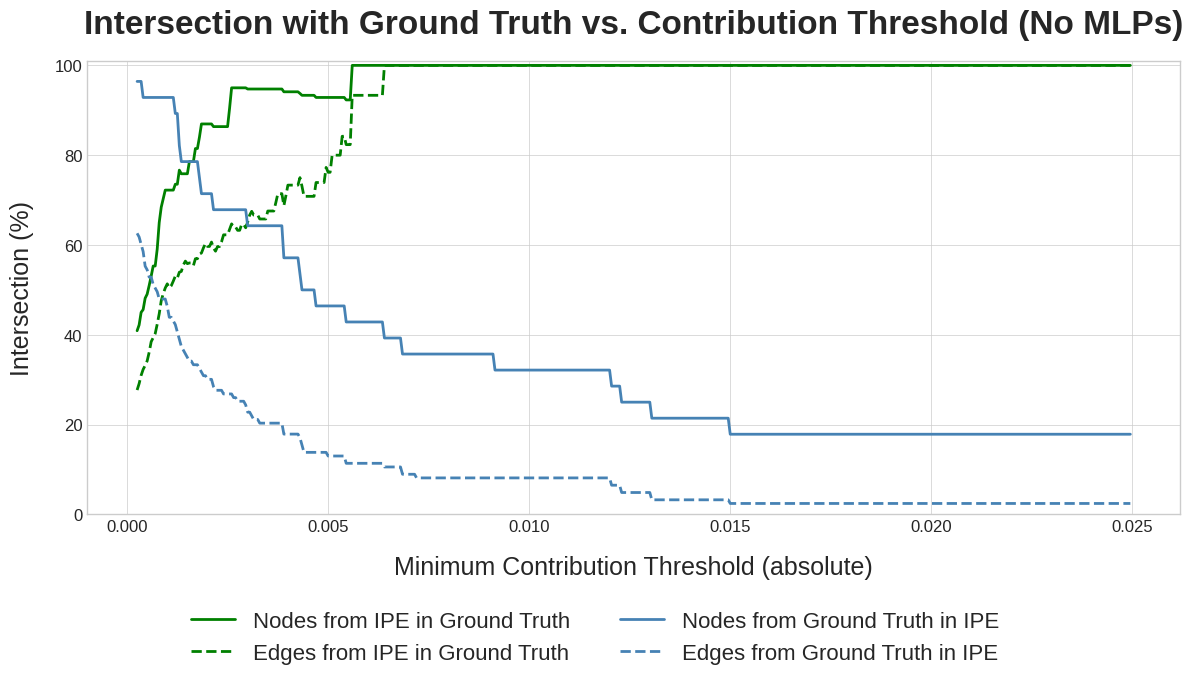

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style

style.use('seaborn-v0_8-whitegrid') # Use a clean and modern style
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Plot the precision for nodes
ax.plot(thresholds, [len(nodes_intersections[i]) / len(our_nodes_by_threshold_no_mlps[i]) * 100 for i in range(len(our_nodes_by_threshold_no_mlps))], linestyle='-', color='green', label='Nodes from IPE in Ground Truth', linewidth=2)

# Plot the precision for edges
ax.plot(thresholds, [len(edges_intersections[i]) / len(our_edges_by_threshold_no_mlps[i]) * 100 for i in range(len(our_edges_by_threshold_no_mlps))], linestyle='--', color='green', label='Edges from IPE in Ground Truth ', linewidth=2)

# Plot the precision for nodes
ax.plot(thresholds, [len(nodes_intersections[i]) / len(ground_nodes) * 100 for i in range(len(our_nodes_by_threshold_no_mlps))], linestyle='-', color='steelblue', label='Nodes from Ground Truth in IPE', linewidth=2)

# Plot the precision for edges
ax.plot(thresholds, [len(edges_intersections[i]) / len(ground_edges) * 100 for i in range(len(our_edges_by_threshold_no_mlps))], linestyle='--', color='steelblue', label='Edges from Ground Truth in IPE', linewidth=2)



if show_all:
	# # Plot the number of edges in circuit
	ax.axhline(y=len(ground_edges) / len(our_edges_by_threshold_no_mlps[0]) * 100, color='red', linestyle='--', label='Percentage of Edges in Ground Truth', linewidth=2)
	ax.plot(thresholds, [len(our_edges_by_threshold_no_mlps[i])/ len(our_edges_by_threshold_no_mlps[0]) * 100 for i in range(len(thresholds))], color='purple', linestyle='--', label='Percentage of Edges in Our Circuit', linewidth=1, alpha=0.7)

	# Plot the number of nodes in the circuit
	ax.axhline(y=len(ground_nodes) / total_nodes * 100, color='orange', linestyle='-', label='Percentage of nodes in Ground Truth', linewidth=1, alpha=0.7)
	ax.plot(thresholds, [len(our_nodes_by_threshold_no_mlps[i])/ total_nodes * 100 for i in range(len(thresholds))], color='purple', linestyle='-', label='Percentage of Nodes in Our Circuit', linewidth=1, alpha=0.7)



ax.set_title('Intersection with Ground Truth vs. Contribution Threshold (No MLPs)', fontsize=24, pad=20, weight='bold')
ax.set_xlabel('Minimum Contribution Threshold (absolute)', fontsize=18, labelpad=15)
ax.set_ylabel('Intersection (%)', fontsize=18, labelpad=15)
ax.set_ylim(0, 101) # Y-axis from 0% to 100%

low = 0.25 if show_all else 0.15
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -low), fontsize=16, ncol=2, frameon=False)


ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='-', linewidth=0.5)

plt.tight_layout()

plt.show()


### 2.1 with MLPs

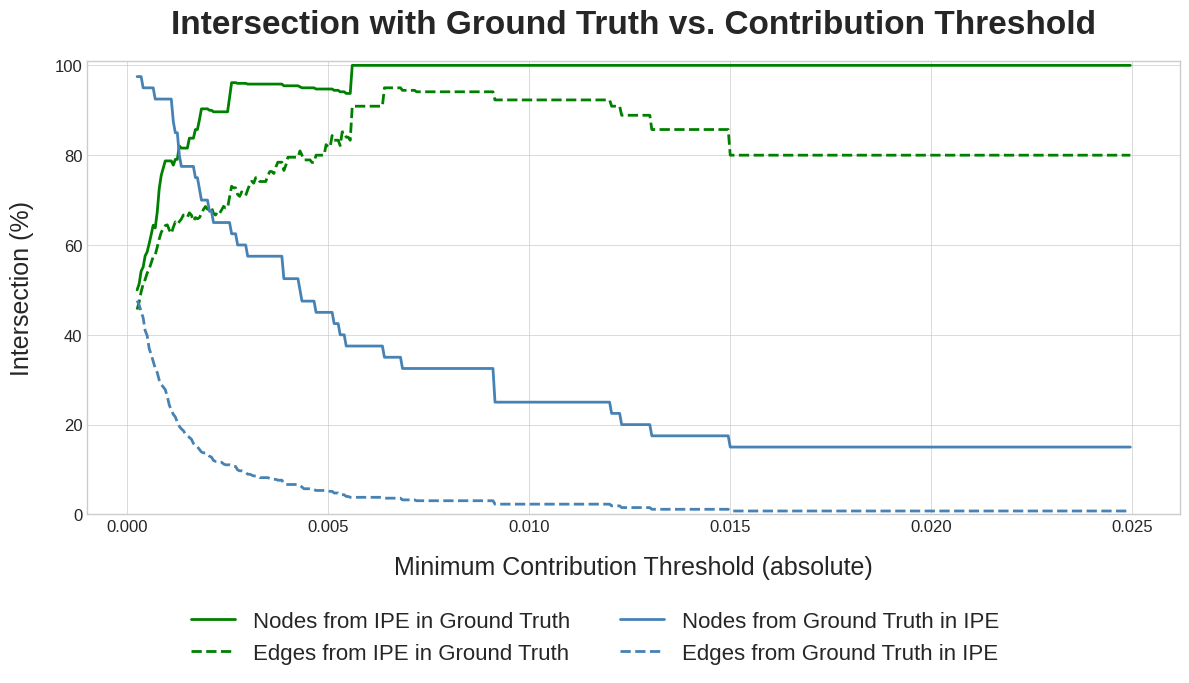

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style

# 4. Create a professional-looking plot
style.use('seaborn-v0_8-whitegrid') # Use a clean and modern style
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Plot the precision for nodes
ax.plot(thresholds, [len(nodes_intersections_with_mlp[i]) / len(our_nodes_by_threshold[i]) * 100 for i in range(len(our_nodes_by_threshold))], linestyle='-', color='green', label='Nodes from IPE in Ground Truth', linewidth=2)

# Plot the precision for edges
ax.plot(thresholds, [len(edges_intersections_with_mlp[i]) / len(our_edges_by_threshold[i]) * 100 for i in range(len(our_edges_by_threshold))], linestyle='--', color='green', label='Edges from IPE in Ground Truth ', linewidth=2)

# Plot the precision for nodes
ax.plot(thresholds, [len(nodes_intersections_with_mlp[i]) / len(ground_nodes_with_mlp) * 100 for i in range(len(our_nodes_by_threshold))], linestyle='-', color='steelblue', label='Nodes from Ground Truth in IPE', linewidth=2)

# Plot the precision for edges
ax.plot(thresholds, [len(edges_intersections_with_mlp[i]) / len(ground_edges_with_mlp) * 100 for i in range(len(our_edges_by_threshold))], linestyle='--', color='steelblue', label='Edges from Ground Truth in IPE', linewidth=2)


if show_all:
	# # Plot the number of edges in circuit
	ax.axhline(y=len(ground_edges_with_mlp) / len(our_edges_by_threshold[0]) * 100, color='red', linestyle='--', label='Percentage of Edges in Ground Truth', linewidth=2)
	ax.plot(thresholds, [len(our_edges_by_threshold[i])/ len(our_edges_by_threshold[0]) * 100 for i in range(len(thresholds))], color='purple', linestyle='--', label='Our Edges', linewidth=1, alpha=0.7)

	# Plot the number of nodes in the circuit
	ax.axhline(y=len(ground_nodes_with_mlp) / total_nodes * 100, color='orange', linestyle='-', label='Percentage of nodes in Ground Truth', linewidth=1, alpha=0.7)
	ax.plot(thresholds, [len(our_nodes_by_threshold[i])/ total_nodes * 100 for i in range(len(thresholds))], color='purple', linestyle='-', label='Our Nodes', linewidth=1, alpha=0.7)






ax.set_title('Intersection with Ground Truth vs. Contribution Threshold', fontsize=24, pad=20, weight='bold')
ax.set_xlabel('Minimum Contribution Threshold (absolute)', fontsize=18, labelpad=15)
ax.set_ylabel('Intersection (%)', fontsize=18, labelpad=15)
ax.set_ylim(0, 101) # Y-axis from 0% to 100%

low = 0.25 if show_all else 0.15
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -low), fontsize=16, ncol=2, frameon=False)


ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='-', linewidth=0.5)

plt.tight_layout()

plt.show()
